# Supplementary Figure S9 — does masking expose the Kv2.1 E423–N179 shift in WT?

This analysis asks whether the E423–N179 pore–VSD/S6 displacement observed in masked L403A predictions is mutation-specific or is also sampled by masked WT. The primary comparison is **WT masked versus L403A masked**, with WT and L403A vanilla ensembles retained as the baseline context.

The experimentally defined shifted state is an **elongated** E423–N179 distance. Its threshold (12.841 Å) is the midpoint between the longest 8SD3 WT subunit and the shortest elongated 8SDA L403A subunit. Because chain labels in a homotetramer can rotate, subunit distances are ranked within each structure before the asymmetry pattern is compared.

Inference uses complete input seeds as the independent units. Recycles are reduced within each seed–AF2-model trajectory, available AF2 models receive equal weight within a seed, and seeds receive equal weight between groups.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

repo_root = Path.cwd()
if not (repo_root / 'shared').is_dir():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from shared.distribution_statistics import parse_trajectory_metadata
from shared.plotting import (
    KV21_PALETTE, apply_kv21_style, experimental_reference_style,
)

apply_kv21_style()

FIG_DIR = repo_root / 'docs/figures/supplementary_figure_s9'
TAB_DIR = repo_root / 'docs/tables/supplementary_figure_s9'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    ('WT', 'vanilla'): repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2test_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
    ('WT', 'masked'): repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
    ('L403A', 'vanilla'): repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_l403a_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
    ('L403A', 'masked'): repo_root / 'kv21/dataDistances/26-02-11_Kv2.1_l403a_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv',
}
DISTANCE_COLUMNS = [f'CA_CA_{chain}_GLU425_CA-{chain}_ASN181_CA' for chain in 'ABCD']
GROUP_ORDER = [('WT', 'vanilla'), ('WT', 'masked'), ('L403A', 'vanilla'), ('L403A', 'masked')]
GROUP_LABELS = {
    ('WT', 'vanilla'): 'WT | vanilla', ('WT', 'masked'): 'WT | masked',
    ('L403A', 'vanilla'): 'L403A | vanilla', ('L403A', 'masked'): 'L403A | masked',
}
GROUP_COLORS = {
    ('WT', 'vanilla'): KV21_PALETTE['WT_VAN'],
    ('WT', 'masked'): KV21_PALETTE['WT_HM'],
    ('L403A', 'vanilla'): KV21_PALETTE['L403A_VAN'],
    ('L403A', 'masked'): KV21_PALETTE['L403A_HM'],
}
BASE_SEED = 20260824
BOOTSTRAP_REPLICATES = 10_000

## Final analysis cohorts and experimental definition

All four ensembles use the same final convergence, tetramer/interface, and alignment-QC level. The CSV residue labels are offset by +2 relative to experimental numbering; `GLU425–ASN181` therefore reports experimental E423–N179.

In [2]:
threshold_table = pd.read_csv(
    repo_root / 'analysis/statistics_revision/seed_block/l403a_experimental_threshold_derivation.csv'
)
SHIFT_THRESHOLD = float(threshold_table.derived_threshold_A.iloc[0])
experimental_ranked = {
    structure: np.sort(part.E423_N179_CA_distance_A.to_numpy(float))
    for structure, part in threshold_table.groupby('structure')
}

frames = {}
audit_rows = []
for key, path in DATASETS.items():
    frame = pd.read_csv(path, usecols=['pdb_file', *DISTANCE_COLUMNS])
    frame = parse_trajectory_metadata(frame)
    frame[DISTANCE_COLUMNS] = frame[DISTANCE_COLUMNS].apply(pd.to_numeric, errors='coerce')
    if frame[DISTANCE_COLUMNS].isna().any().any():
        raise ValueError(f'Missing E423–N179 values in {key}')
    ranked = np.sort(frame[DISTANCE_COLUMNS].to_numpy(float), axis=1)
    for index in range(4):
        frame[f'rank_{index + 1}_A'] = ranked[:, index]
    frame['maximum_distance_A'] = ranked[:, -1]
    frame['shifted_subunits'] = (ranked >= SHIFT_THRESHOLD).sum(axis=1)
    frame['any_shifted'] = frame.shifted_subunits.ge(1).astype(float)
    for number in range(1, 5):
        frame[f'exactly_{number}_shifted'] = frame.shifted_subunits.eq(number).astype(float)
    frames[key] = frame
    audit_rows.append({
        'sequence': key[0], 'protocol': key[1], 'source_path': str(path.relative_to(repo_root)),
        'snapshot_rows': len(frame), 'retained_seeds': frame.seed.nunique(),
        'retained_seed_model_trajectories': frame[['seed', 'model_number']].drop_duplicates().shape[0],
        'threshold_A': SHIFT_THRESHOLD,
    })

cohort_audit = pd.DataFrame(audit_rows)
cohort_audit.to_csv(TAB_DIR / 'e423_n179_cohort_audit.csv', index=False)
display(cohort_audit)

,sequence,protocol,source_path,snapshot_rows,retained_seeds,retained_seed_model_trajectories,threshold_A
0,WT,vanilla,kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF...,4562,100,487,12.841337
1,WT,masked,kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2...,3658,100,419,12.841337
2,L403A,vanilla,kv21/dataDistances/26-02-11_Kv2.1_l403a_vanill...,4371,100,479,12.841337
3,L403A,masked,kv21/dataDistances/26-02-11_Kv2.1_l403a_masked...,3693,100,426,12.841337


## Seed-balanced summaries and contrasts

The continuous endpoint is the maximum E423–N179 distance across the tetramer: each trajectory contributes its median retained recycle, AF2 models are averaged within seed, and seeds are averaged between groups. Shifted-state endpoints first calculate the fraction of retained snapshots within each trajectory and then apply the same model-within-seed weighting.

Confidence intervals are percentile intervals from 10,000 independent whole-seed bootstrap draws. Identical numerical seed labels are not treated as paired observations across separate prediction runs.

In [3]:
def seed_summary(frame, column, reduction):
    grouped = frame.groupby(['seed', 'model_number'])[column]
    trajectories = grouped.median() if reduction == 'median' else grouped.mean()
    return trajectories.groupby('seed').mean().sort_index()


metric_definitions = {
    'maximum_distance_A': ('maximum_distance_A', 'median', 'Å'),
    'any_shifted_fraction': ('any_shifted', 'mean', 'fraction'),
    'exactly_two_shifted_fraction': ('exactly_2_shifted', 'mean', 'fraction'),
    'four_shifted_fraction': ('exactly_4_shifted', 'mean', 'fraction'),
}
seed_values = {
    key: {
        metric: seed_summary(frame, column, reduction)
        for metric, (column, reduction, _) in metric_definitions.items()
    }
    for key, frame in frames.items()
}

# Ranked subunit values for the masked-only distribution panel.
rank_seed_values = {}
for key in [('WT', 'masked'), ('L403A', 'masked')]:
    rank_seed_values[key] = {
        rank_number: seed_summary(frames[key], f'rank_{rank_number}_A', 'median')
        for rank_number in range(1, 5)
    }

bootstrap_draws = {}
summary_rows = []
for group_index, key in enumerate(GROUP_ORDER):
    bootstrap_draws[key] = {}
    for metric_index, (metric, (_, reduction, unit)) in enumerate(metric_definitions.items()):
        values = seed_values[key][metric].to_numpy(float)
        rng = np.random.default_rng(BASE_SEED + 100 * group_index + metric_index)
        draws = values[rng.integers(0, len(values), size=(BOOTSTRAP_REPLICATES, len(values)))].mean(axis=1)
        bootstrap_draws[key][metric] = draws
        summary_rows.append({
            'sequence': key[0], 'protocol': key[1], 'metric': metric,
            'seed_balanced_estimate': values.mean(),
            'ci_low': np.quantile(draws, .025), 'ci_high': np.quantile(draws, .975),
            'unit': unit, 'within_trajectory_reduction': reduction,
            'retained_seeds': len(values), 'bootstrap_replicates': BOOTSTRAP_REPLICATES,
        })
group_summary = pd.DataFrame(summary_rows)

contrast_definitions = {
    'L403A_minus_WT__masked': (('WT', 'masked'), ('L403A', 'masked')),
    'L403A_minus_WT__vanilla': (('WT', 'vanilla'), ('L403A', 'vanilla')),
    'masked_minus_vanilla__WT': (('WT', 'vanilla'), ('WT', 'masked')),
    'masked_minus_vanilla__L403A': (('L403A', 'vanilla'), ('L403A', 'masked')),
}
contrast_rows = []
for metric, (_, _, unit) in metric_definitions.items():
    for label, (group_a, group_b) in contrast_definitions.items():
        samples = bootstrap_draws[group_b][metric] - bootstrap_draws[group_a][metric]
        contrast_rows.append({
            'metric': metric, 'contrast': label,
            'estimate': seed_values[group_b][metric].mean() - seed_values[group_a][metric].mean(),
            'ci_low': np.quantile(samples, .025), 'ci_high': np.quantile(samples, .975),
            'unit': unit, 'bootstrap_replicates': BOOTSTRAP_REPLICATES,
        })
    interaction_samples = (
        bootstrap_draws[('L403A', 'masked')][metric]
        - bootstrap_draws[('L403A', 'vanilla')][metric]
        - bootstrap_draws[('WT', 'masked')][metric]
        + bootstrap_draws[('WT', 'vanilla')][metric]
    )
    interaction_estimate = (
        seed_values[('L403A', 'masked')][metric].mean()
        - seed_values[('L403A', 'vanilla')][metric].mean()
        - seed_values[('WT', 'masked')][metric].mean()
        + seed_values[('WT', 'vanilla')][metric].mean()
    )
    contrast_rows.append({
        'metric': metric, 'contrast': 'masking_by_L403A_interaction',
        'estimate': interaction_estimate,
        'ci_low': np.quantile(interaction_samples, .025),
        'ci_high': np.quantile(interaction_samples, .975),
        'unit': unit, 'bootstrap_replicates': BOOTSTRAP_REPLICATES,
    })
contrasts = pd.DataFrame(contrast_rows)

# Full shifted-subunit occupancy for the two masked ensembles.
occupancy_rows = []
occupancy_draws = {}
for group_index, key in enumerate([('WT', 'masked'), ('L403A', 'masked')]):
    occupancy_draws[key] = {}
    for number in range(1, 5):
        values = seed_summary(frames[key], f'exactly_{number}_shifted', 'mean').to_numpy(float)
        rng = np.random.default_rng(BASE_SEED + 1000 + 10 * group_index + number)
        draws = values[rng.integers(0, len(values), size=(BOOTSTRAP_REPLICATES, len(values)))].mean(axis=1)
        occupancy_draws[key][number] = draws
        occupancy_rows.append({
            'sequence': key[0], 'protocol': key[1], 'shifted_subunits': number,
            'seed_balanced_fraction': values.mean(),
            'ci_low': np.quantile(draws, .025), 'ci_high': np.quantile(draws, .975),
        })
occupancy = pd.DataFrame(occupancy_rows)

seed_level_long = pd.concat([
    pd.DataFrame({
        'sequence': key[0], 'protocol': key[1], 'seed': values.index,
        'metric': metric, 'value': values.to_numpy(float),
    })
    for key in GROUP_ORDER for metric, values in seed_values[key].items()
], ignore_index=True)

group_summary.to_csv(TAB_DIR / 'e423_n179_group_summary.csv', index=False)
contrasts.to_csv(TAB_DIR / 'e423_n179_seed_bootstrap_contrasts.csv', index=False)
occupancy.to_csv(TAB_DIR / 'e423_n179_masked_shifted_subunit_occupancy.csv', index=False)
seed_level_long.to_csv(TAB_DIR / 'e423_n179_seed_level_values.csv', index=False)

display(group_summary.pivot(index=['sequence', 'protocol'], columns='metric', values='seed_balanced_estimate').round(4))
display(contrasts[contrasts.contrast.isin(['L403A_minus_WT__masked', 'masking_by_L403A_interaction'])].round(4))

metric             any_shifted_fraction  exactly_two_shifted_fraction  \
sequence protocol                                                       
L403A    masked                  0.0983                        0.0034   
         vanilla                 0.0002                        0.0002   
WT       masked                  0.1435                        0.0047   
         vanilla                 0.0015                        0.0000   

metric             four_shifted_fraction  maximum_distance_A  
sequence protocol                                             
L403A    masked                   0.0902             11.1540  
         vanilla                  0.0000             10.2030  
WT       masked                   0.1299             11.3474  
         vanilla                  0.0000             10.5318

,metric,contrast,estimate,ci_low,ci_high,unit,bootstrap_replicates
0,maximum_distance_A,L403A_minus_WT__masked,-0.1934,-0.3011,-0.0843,Å,10000
4,maximum_distance_A,masking_by_L403A_interaction,0.1354,0.0137,0.2531,Å,10000
5,any_shifted_fraction,L403A_minus_WT__masked,-0.0453,-0.0791,-0.0107,fraction,10000
9,any_shifted_fraction,masking_by_L403A_interaction,-0.0440,-0.0777,-0.0092,fraction,10000
10,exactly_two_shifted_fraction,L403A_minus_WT__masked,-0.0013,-0.0045,0.0019,fraction,10000
14,exactly_two_shifted_fraction,masking_by_L403A_interaction,-0.0016,-0.0047,0.0017,fraction,10000
15,four_shifted_fraction,L403A_minus_WT__masked,-0.0397,-0.0726,-0.0074,fraction,10000
19,four_shifted_fraction,masking_by_L403A_interaction,-0.0397,-0.0726,-0.0074,fraction,10000


## Supplementary figure

Panel A compares ranked subunit distances within the two masked ensembles and overlays the ranked experimental structures. Panel B places the maximum tetramer distance in the four-group factorial context. Panel C reports the absolute prevalence of any threshold-crossing subunit. Panel D resolves the masked shifted tail by the number of shifted subunits.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


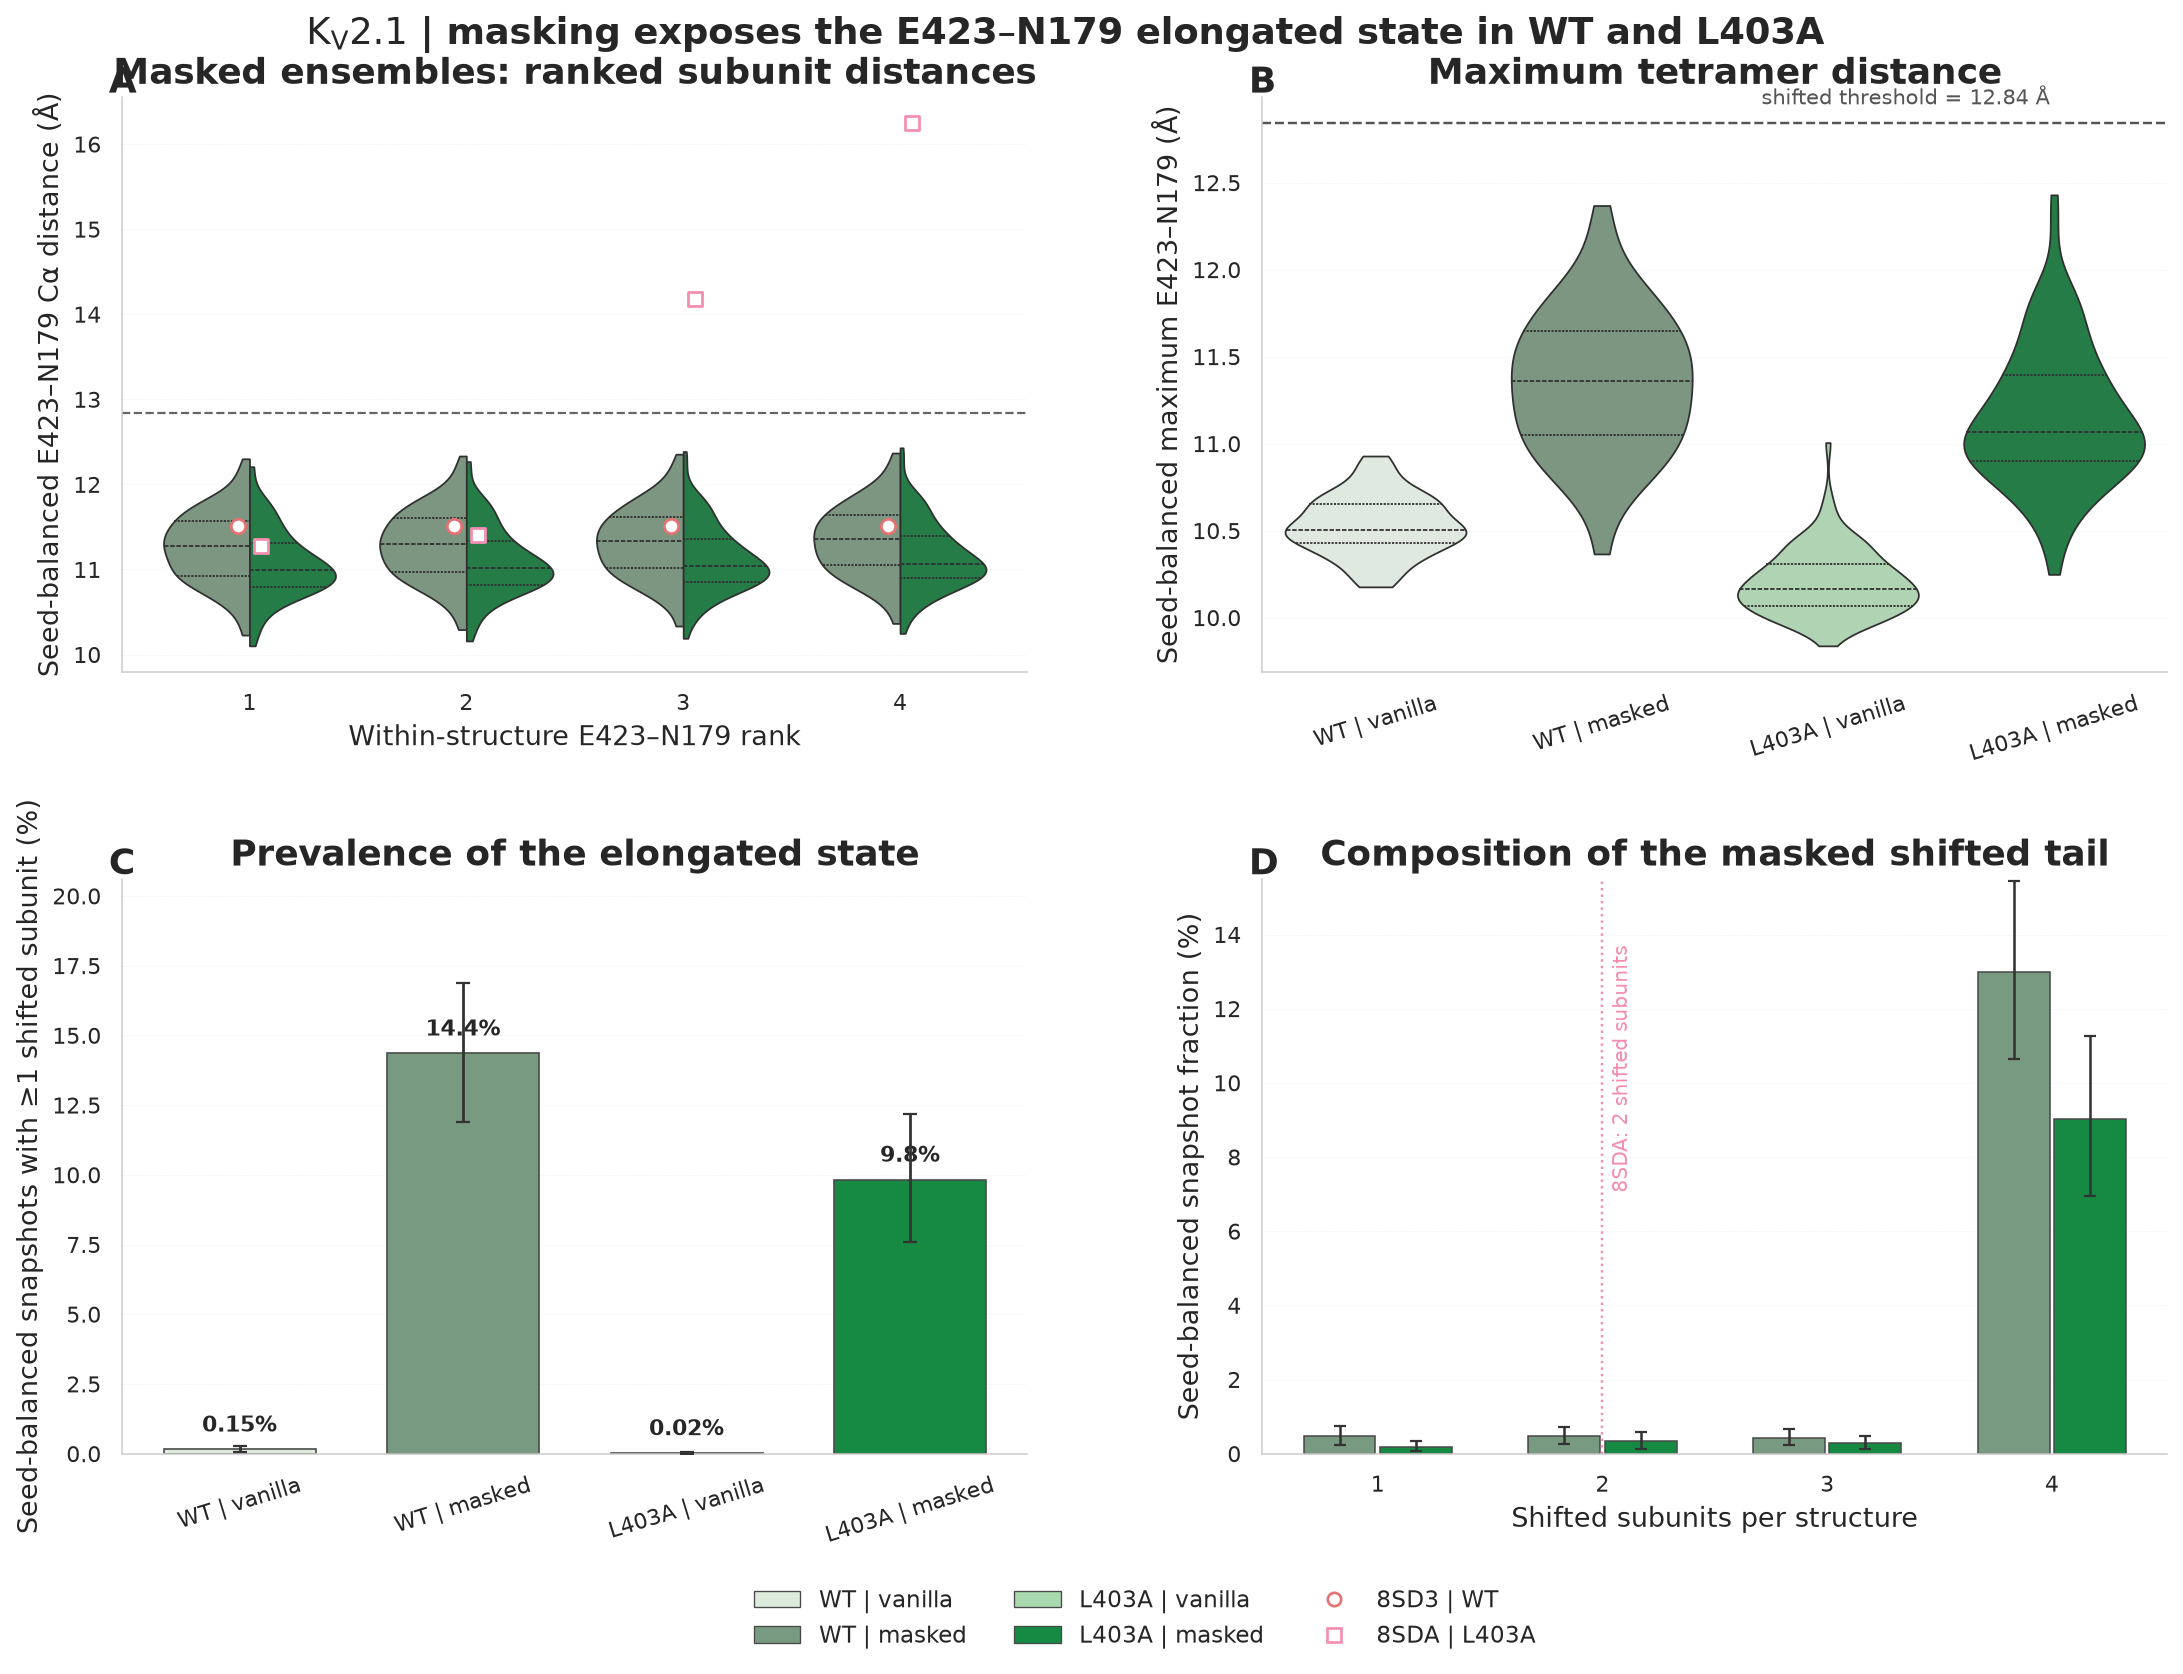

Saved: docs/figures/supplementary_figure_s9/Figure_S9_Kv21_L403A_masked_WT_vs_mutant.png
Saved: docs/figures/supplementary_figure_s9/Figure_S9_Kv21_L403A_masked_WT_vs_mutant.pdf


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14.2, 10.8), facecolor='white')
fig.subplots_adjust(left=.085, right=.985, top=.935, bottom=.15, hspace=.36, wspace=.26)
ax_a, ax_b, ax_c, ax_d = axes.ravel()

# A: ranked subunit distances in masked WT versus masked L403A.
rank_records = []
for key in [('WT', 'masked'), ('L403A', 'masked')]:
    for rank_number, values in rank_seed_values[key].items():
        rank_records.extend({
            'Sequence': key[0], 'Rank': f'{rank_number}', 'Distance': value,
        } for value in values)
rank_plot = pd.DataFrame(rank_records)
sns.violinplot(
    data=rank_plot, x='Rank', y='Distance', hue='Sequence',
    order=['1', '2', '3', '4'], hue_order=['WT', 'L403A'], split=True,
    inner='quartile', cut=0, linewidth=.8,
    palette={'WT': GROUP_COLORS[('WT', 'masked')], 'L403A': GROUP_COLORS[('L403A', 'masked')]},
    ax=ax_a,
)
for rank_index in range(4):
    for structure, offset in [('8SD3', -.055), ('8SDA', .055)]:
        style = experimental_reference_style(structure)
        ax_a.scatter(
            rank_index + offset, experimental_ranked[structure][rank_index],
            s=42, marker=style['marker'], facecolor='white', edgecolor=style['color'],
            linewidth=1.25, zorder=8,
        )
ax_a.axhline(SHIFT_THRESHOLD, color='#666666', ls='--', lw=1.0)
ax_a.set(
    title='Masked ensembles: ranked subunit distances',
    xlabel='Within-structure E423–N179 rank', ylabel='Seed-balanced E423–N179 Cα distance (Å)',
)
ax_a.get_legend().remove()

# B: maximum distance in all four groups.
max_records = []
for key in GROUP_ORDER:
    max_records.extend({
        'Group': GROUP_LABELS[key], 'Maximum': value,
    } for value in seed_values[key]['maximum_distance_A'])
max_plot = pd.DataFrame(max_records)
label_order = [GROUP_LABELS[key] for key in GROUP_ORDER]
palette = {GROUP_LABELS[key]: GROUP_COLORS[key] for key in GROUP_ORDER}
sns.violinplot(
    data=max_plot, x='Group', y='Maximum', hue='Group', order=label_order,
    palette=palette, inner='quartile', cut=0, linewidth=.8, legend=False, ax=ax_b,
)
ax_b.axhline(SHIFT_THRESHOLD, color='#555555', ls='--', lw=1.1)
ax_b.text(2.98, SHIFT_THRESHOLD + .08, f'shifted threshold = {SHIFT_THRESHOLD:.2f} Å',
          ha='right', va='bottom', fontsize=9.5, color='#555555')
ax_b.set(
    title='Maximum tetramer distance', xlabel='',
    ylabel='Seed-balanced maximum E423–N179 (Å)',
)
ax_b.tick_params(axis='x', rotation=17)

# C: absolute prevalence of any shifted subunit.
any_summary = group_summary[group_summary.metric.eq('any_shifted_fraction')].copy()
any_summary['key'] = list(zip(any_summary.sequence, any_summary.protocol))
any_summary = any_summary.set_index('key').loc[GROUP_ORDER].reset_index()
x = np.arange(4)
y = any_summary.seed_balanced_estimate.to_numpy(float) * 100
lo = any_summary.ci_low.to_numpy(float) * 100
hi = any_summary.ci_high.to_numpy(float) * 100
bars = ax_c.bar(
    x, y, width=.68, color=[GROUP_COLORS[key] for key in GROUP_ORDER],
    edgecolor='#4A4A4A', linewidth=.75,
)
ax_c.errorbar(x, y, yerr=[y - lo, hi - y], fmt='none', ecolor='#333333',
              elinewidth=1.25, capsize=3, zorder=4)
for bar, value in zip(bars, y):
    label = f'{value:.2f}%' if value < 1 else f'{value:.1f}%'
    ax_c.text(bar.get_x() + bar.get_width()/2, value + .45, label,
              ha='center', va='bottom', fontsize=10, fontweight='semibold')
ax_c.set_xticks(x, label_order, rotation=17)
ax_c.set(
    title='Prevalence of the elongated state', xlabel='',
    ylabel='Seed-balanced snapshots with ≥1 shifted subunit (%)',
)
ax_c.set_ylim(0, max(18, hi.max() * 1.22))

# D: number of shifted subunits in the masked tail (unconditional frequencies).
offsets = {'WT': -.17, 'L403A': .17}
for sequence, color in [('WT', GROUP_COLORS[('WT', 'masked')]),
                        ('L403A', GROUP_COLORS[('L403A', 'masked')])]:
    part = occupancy[occupancy.sequence.eq(sequence)].sort_values('shifted_subunits')
    xx = np.arange(1, 5) + offsets[sequence]
    yy = part.seed_balanced_fraction.to_numpy(float) * 100
    lower = part.ci_low.to_numpy(float) * 100
    upper = part.ci_high.to_numpy(float) * 100
    ax_d.bar(xx, yy, width=.32, color=color, edgecolor='#4A4A4A', linewidth=.7)
    ax_d.errorbar(xx, yy, yerr=[yy-lower, upper-yy], fmt='none', ecolor='#333333',
                  elinewidth=1.15, capsize=2.5, zorder=4)
ax_d.axvline(2, color=experimental_reference_style('8SDA')['color'], lw=1.1, ls=':')
ax_d.text(2.04, 13.7, '8SDA: 2 shifted subunits', rotation=90, ha='left', va='top',
          fontsize=9.2, color=experimental_reference_style('8SDA')['color'])
ax_d.set_xticks(range(1, 5))
ax_d.set(
    title='Composition of the masked shifted tail', xlabel='Shifted subunits per structure',
    ylabel='Seed-balanced snapshot fraction (%)',
)
ax_d.set_ylim(0, 15.5)

for label, axis in zip('ABCD', axes.ravel()):
    axis.text(-.015, 1.055, label, transform=axis.transAxes, fontsize=16,
              fontweight='bold', ha='left', va='top')
    axis.grid(axis='x', visible=False)
    sns.despine(ax=axis)

wt_exp_style = experimental_reference_style('8SD3')
mut_exp_style = experimental_reference_style('8SDA')
legend_handles = [
    Patch(facecolor=GROUP_COLORS[key], edgecolor='#4A4A4A', label=GROUP_LABELS[key])
    for key in GROUP_ORDER
] + [
    Line2D([0], [0], marker=wt_exp_style['marker'], color='none', markerfacecolor='white',
           markeredgecolor=wt_exp_style['color'], markeredgewidth=1.2, label='8SD3 | WT'),
    Line2D([0], [0], marker=mut_exp_style['marker'], color='none', markerfacecolor='white',
           markeredgecolor=mut_exp_style['color'], markeredgewidth=1.2, label='8SDA | L403A'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(.535, .025),
           ncol=3, frameon=False, fontsize=10.5)
fig.suptitle(
    r'$\mathrm{K}_{\mathrm{V}}2.1$ | masking exposes the E423–N179 elongated state in WT and L403A',
    fontsize=16.5, fontweight='semibold', y=.982,
)

png = FIG_DIR / 'Figure_S9_Kv21_L403A_masked_WT_vs_mutant.png'
pdf = FIG_DIR / 'Figure_S9_Kv21_L403A_masked_WT_vs_mutant.pdf'
fig.savefig(png, dpi=400, bbox_inches='tight', facecolor='white')
fig.savefig(pdf, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig)
print('Saved:', png.relative_to(repo_root))
print('Saved:', pdf.relative_to(repo_root))

## Take-home message

The elongated E423–N179 state is **not specific to L403A**. Targeted masking makes it appreciable in both sequence backgrounds, while both vanilla ensembles remain near zero. In the final matched-QC cohorts, WT masked has a higher absolute shifted-state prevalence than L403A masked (~14.4% versus ~9.8%), and its maximum-distance distribution is ~0.19 Å higher.

The relative continuous response to masking is nevertheless slightly larger from the lower L403A vanilla baseline: the maximum-distance masking effect is ~0.95 Å in L403A and ~0.82 Å in WT. Thus, masking broadens access to the elongated coordinate in both proteins, but this single coordinate does not support selective stabilization of the thresholded state by L403A.

Finally, the predicted threshold-positive tail is predominantly a **four-subunit elongation** in both masked ensembles. Exactly two shifted subunits—the asymmetric pattern in experimental 8SDA—remain rare. The supplemental interpretation should therefore emphasize increased sampling of an elongated pore–VSD/S6 coordinate, not full recovery of the mutation-specific experimental conformer.